<a href="https://colab.research.google.com/github/nicolacalzone/RAG_ChatBot_HarryPotter/blob/main/CalzoneNicola_VendraminRiccardo_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Harry Potter RAG ChatBot  


| Student Name       | Master Program                    |
|--------------------|------------------------------------|
| Calzone Nicola     | Computer Engineering (AI and Robotics) |
| Vendramin Riccardo | Computer Engineering (AI and Robotics) |


University of Padova, *Natural Language Processing* — Prof. Giorgio Satta — 2023/24

## Domain

This chatbot is designed to be a comprehensive guide and assistant for all things related to the enchanting universe of the **Harry Potter saga**, written by **J.K. Rowling**.

We wanted this system to answer whether you have general questions about the wizarding world or specific inquiries about the characters, plot twists, magical spells, or mythical creatures.

The chatbot is intended to serve both new readers starting their first journey into the Hogwarts School of Witchcraft and Wizardry, as well as experienced fans revisiting the saga. The aim of this chatbot is to make the reading experience better, and provide accurate responses to queries.

In [ ]:
!pip install -U -q "langchain" "transformers==4.31.0" "datasets==2.13.0" "peft==0.4.0" "accelerate==0.21.0" "bitsandbytes==0.40.2" "trl==0.4.7" "safetensors>=0.3.1" "langchain-community"

## Dataset Discussion


### First attempt
We started with two structured datasets: [**saracandu/harry-potter-trivia-ai**](https://huggingface.co/datasets/saracandu/harrypotter-trivia-ai-new) and [**PotterDB**](https://potterdb.com).

We converted structured data from the dataset into plain text. For instance:
- **Character:** Dumbledore
- **Family members:** Percival Dumbledore (father), Kendra Dumbledore (mother)
- **House:** Gryffindor
- etc.

Would result in: "Dumbledore, son of Percival Dumbledore (father) and Kendra Dumbledore (mother), from the Gryffindor House, etc."

However, these datasets could sometimes lack character descriptions and their personality features, other than missing a lot of crucial plot information.

### Second attempt

To address this problem, we incorporated plain text from all 7 Harry Potter books ([**WutYee/HarryPotter_books_1to7**](https://huggingface.co/datasets/WutYee/HarryPotter_books_1to7)). Surprisingly, the retrieved documents predominantly came from the books rather than the structured datasets. We therefore decided to remove the initial datasets, and this choice further enhanced the answer quality.

### Our key insight

Structured datasets sacrifice depth and richness found in original text, while unstructured text allows flexible retrieval. The ChatBot leverages unstructured content, accessing information from any part of the text without predefined categories or structures.

In [ ]:
!git clone https://huggingface.co/datasets/WutYee/HarryPotter_books_1to7

Function:    `clean_text`

Description: Used to normalize and standardize the input text.

Parameters:  `file_path`   --> Specifies the path to a *.txt* file

Return:      `text`        --> Returns the cleaned text

---

The function `clean_text` utilizes `re` library to perform the following operations:
- Eliminate unwanted characters, punctuation and numbers
- Remove titles of the chapter chapters
- Join words that have been split across two lines
- Connect sentences that have been erroneously split by '`\n`'
- Separate words from the (remaining) adjacent punctuation
- Expand acronyms into their entire forms


In [ ]:
import re

def clean_text(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()

    text = re.sub(r'\n?\d+\n', ' ', text)
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)

    text = re.sub(r'\x91', '', text)
    text = re.sub(r"[\"\'\-\“\”\’\—\…]", '', text)
    text = re.sub(r'(\w)([^\w\s])', r'\1 \2', text)  # Add space before punctuation
    text = re.sub(r'([^\w\s])(\w)', r'\1 \2', text)  # Add space after punctuation
    text = re.sub(r'([^\w\s])([^\w\s])', r'\1 \2', text) # Add space between consecutive punctuation signs

    text = re.sub(r'Chapter \d+', 'Chapter', text)
    text = re.sub(r'\n?Chapter\n?', '', text)

    text = re.sub(r'([a-z])\n([a-z])', r'\1 \2', text)
    text = re.sub(r'([a-z])\n([A-Z])', r'\1 \2', text)
    text = re.sub(r'\n([a-z])', r' \1', text)

    text = re.sub(r'\.\.\.', '', text)
    text = re.sub(r'\.\s\.\s\.', '', text)

    text = re.sub(r'\n+', '\n', text)

    replacements = {
      r'N\s\.\sE\s\.\sW\s\.\sT\s\.': "Nastily Exhausting Wizarding Test",
      r'S\s\.\sP\s\.\sE\s\.\sW\s\.': "Society for the Promotion of Elfish Welfare",
      r'O\s\.\sW\s\.\sL\s\.': "Ordinary Wizarding Level",
      r'J\s\.\sK\s\.': "JK"
    }
    for pattern, replacement in replacements.items():
      text = re.sub(pattern, replacement, text)

    return text

Here we load the books from the system and apply the above descripted function '`clean_text`'.

We then load the entire dataset into the variable '`data`' which is a `List` of `Document` objects.

In [ ]:
import os

book_dir = './HarryPotter_books_1to7/'
folders = ['test', 'train', 'validation']
cleaned_folder = './cleaned_books'
cleaned_books = []
cleaned_text = ''
cleaned_file_path = './cleaned_books.txt'

for folder in folders:
  folder_path = os.path.join(book_dir, folder)
  files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
  for file in files:
    file_path = os.path.join(folder_path, file)
    cleaned_text += clean_text(file_path)

with open(cleaned_file_path, 'w', encoding='utf-8') as file:
  file.write(cleaned_text)

In [ ]:
from langchain.document_loaders import TextLoader

loader = TextLoader(cleaned_file_path)
data = loader.load()

## Split data

### RecursiveCharacterTextSplitter
The LangChain library is a powerful tool and one of task it allows to address is the split of text into smaller chunks, thanks to the '`text_splitter`' module. This module offers many methods, in particular we use '`RecursiveCharacterTextSplitter`'. The choice was driven to assure context-aware splitting, to preserve coherence of the plot. Recursive splitter is in fact designed to split text into smaller chunks while preserving the context and coherence of the text as much as possible. This is achieved through recursive splitting based on character-level analysis.

### Experiments
We tried different values for '`chunk_size`' which define the maximum size of each chunk and for '`chunk_overlap`', which specifies the number of characters that overlap between consecutive chunks, ensuring that important information is not lost at the boundaries.

We tried different '`chunk_size`' values, and we saw that ones below 500 lead to incorrect answers, while increasing it generates more precise answers. We choose 1000 because larger values do not improve the answers and massively reduce the number of documents.

For the '`chunk_overlap`' we keep it in the range of 20%-30% of the '`chunk_size`'. This choice was made because of loss of context for sentences at the begin and at the end of the chunk. So, since context in our case is crucial to generate valid answers, a slightly higher overlap ensure to preserve context at any point.

In [31]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=300, add_start_index=True
)
all_splits = text_splitter.split_documents(data)

## Dataset Analysis & Statistics

In this section, we conducted a comprehensive statistics and analysis of our dataset.


####Number of words
Initially, we calculated the total number of **types** in the dataset, including repetitions, which is stored in the variable `corpus_size`.
We also determined the number of unique **tokens** present in the vocabulary, represented by the variable `vocabulary_size`. This gave us an understanding of the diversity and richness of the language used in the text.

Subsequently, we utilized the `Counter` object from the `collections` library to identify the **10 most frequent tokens** in the text. This helped us to understand the most common elements in our dataset.

####Lemmatization
We calculated the number of **lemmas** to understand the morphological variations in our dataset.


####Average lengths
We then computed the **average length** of a chunk, the **median length**, and the **maximum length**. Interestingly, despite setting a limit of 1000 characters per chunk, we observed that the maximum size of a chunk was only 231 characters. Additionally, we performed the same analysis to the **sentence lengths**.


####Plots
Finally, we visualized our findings by plotting histograms of chunks and sentences' lengths. This allowed us to better understand the distribution of chunk lengths and identify any pattern or outlier in our data.
We plotted word clouds both for lemmas and for the vocabulary to visually represent the most frequent words.

Through this statistical analysis, we were able to gain valuable insights into the structure and characteristics of our dataset.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import string

Stop words are common words like “and”, “the”, “is”, etc., and we have filtered them out because they occur frequently but offer little meaningful information for our analysis.

In [33]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### Number of words

In [34]:
corpus = data[0].page_content

corpus_size = len(corpus)
print("Total number of types, |N| = " + str(corpus_size))

words = corpus.split()
vocabulary_size = len(set(words))
print("Total number of unique tokens, |V| = " + str(vocabulary_size))

Total number of types, |N| = 6493614
Total number of unique tokens, |V| = 29854


In [35]:
filtered_words = [word for word in words if word.lower() not in stop_words and word not in punctuation]
word_counts = Counter(filtered_words)
most_common_words = word_counts.most_common(10)
print("Most common word-forms and their frequencies:", most_common_words)

Most common word-forms and their frequencies: [('Harry', 17779), ('said', 14422), ('Ron', 5777), ('Hermione', 4940), ('back', 3187), ('Dumbledore', 2897), ('could', 2759), ('looked', 2349), ('one', 2302), ('like', 2290)]


### Lemmatization

In [36]:
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmas

filtered_text = " ".join(filtered_words).lower()
lemmas = lemmatize_text(filtered_text)
unique_lemmas = set(lemmas)
num_lemmas = len(unique_lemmas)
print(f"Total number of unique lemmas: {num_lemmas}")

Total number of unique lemmas: 22526


### Average lengths

In [37]:
### CHUNKS ###
chunk_lengths = [len(doc.page_content.split()) for doc in all_splits]

max_chunk_lenght = np.max(chunk_lengths)
average_chunk_length = np.mean(chunk_lengths)
median_chunk_length = np.median(chunk_lengths)

print("About CHUNKS\n\nNumber of documents:\t " + str(len(all_splits)))
print(f"Max Chunk Length:\t {max_chunk_lenght}")
print(f"Avg Chunk Length:\t {average_chunk_length:.2f}")
print(f"Median Chunk Length:\t {median_chunk_length}")

### SENTENCES ###
sentences = re.split(r'[.!?]+', corpus)
num_sentences = len(sentences)

sentence_lengths = [len(s) for s in sentences if len(s) > 5]

average_length = np.mean(sentence_lengths)
median_length = np.median(sentence_lengths)
max_length = np.max(sentence_lengths)

print("\nAbout SENTENCES\n\nThe number of sentences in the text:\t", num_sentences)
print(f"The average length of a sentence:\t{average_length:.2f}")
print(f"The median length of a sentence:\t{median_length}")
print(f"The maximum length of a sentence:\t{max_length}")

About CHUNKS

Number of documents:	 9272
Max Chunk Length:	 231
Avg Chunk Length:	 176.44
Median Chunk Length:	 182.0

About SENTENCES

The number of sentences in the text:	 85157
The average length of a sentence:	77.11
The median length of a sentence:	59.0
The maximum length of a sentence:	1096


### Plots

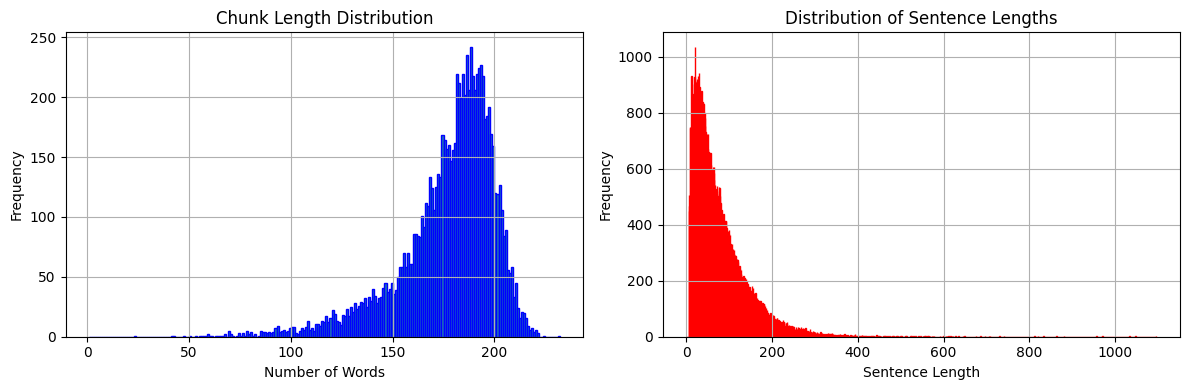

In [38]:
plt.figure(figsize=(12, 4))  # Increase the figure width to accommodate both histograms
plt.subplot(1, 2, 1)
plt.hist(chunk_lengths, bins=range(1, max(chunk_lengths) + 2), edgecolor='blue')
plt.title('Chunk Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)

# Plot the second histogram
plt.subplot(1, 2, 2)
plt.hist(sentence_lengths, bins=range(0, max(sentence_lengths) + 1), edgecolor='red')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

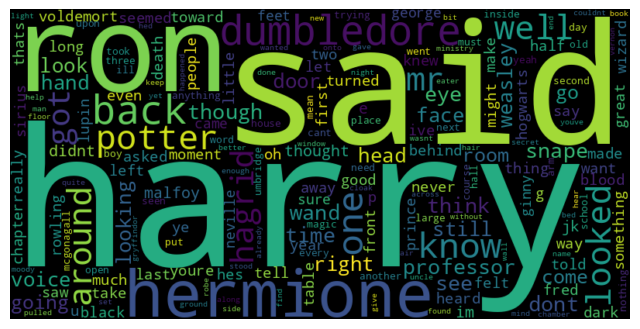

In [39]:
wordcloud = WordCloud(collocations=False, width=800, height=400).generate(filtered_text)
# Display the word cloud for the Word-Forms (filtered)
plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
wordcloud = WordCloud(collocations=False, width=800, height=400).generate(" ".join(lemmas))
# Display the word cloud for the Lemmas
plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Vector Store

The langchain library provides robust tools for embedding and storing text data efficiently. In this step we employ `CacheBackedEmbeddings` to use cache to improve elapsing time and `FAISS`, which facilitate embedding large amounts of text and storing these embeddings for quick retrieval, respectively.
- `LocalFileStore`: A simple, file-based storage system to persist cached embeddings locally.
- `HuggingFaceEmbeddings`: This class leverages pre-trained models from the Hugging Face library to generate embeddings for textual data.
- `CacheBackedEmbeddings`: This class adds a caching layer to the embedding process, allowing for efficient re-use of previously computed embeddings, thus speeding up the embedding process and saving computational resources.
- `FAISS`: A powerful library for efficient similarity search and clustering of dense vectors, developed by *Facebook AI Research*. It is used for storing and querying vector embeddings.

The langchain library enables efficient retrieval of relevant documents based on text queries using embeddings. By leveraging a `FAISS` vector store, we can perform fast similarity searches over large sets of document embeddings. The retriever component facilitates querying the vector store to find the most relevant documents based on a given input query.


In [ ]:
!pip install -q -U faiss-cpu tiktoken sentence-transformers

In [ ]:
from langchain.embeddings import CacheBackedEmbeddings, HuggingFaceEmbeddings
from langchain.storage import LocalFileStore

### Experiments and results

We tried both different vector stores and different embedders, it follow a brief comparison and a comment to motivate our final choice. <br>

---

#### Embed model

<table>
  <tr>
    <th>ID</th>
    <th>Avg Performance <br>(Sentence Embedding and Semantic Search)</th>
    <th>Speed <br>(sentences/sec)</th>
    <th>Model Size (MB)</th>
    <th>Dimensions</th>
  </tr>
  <tr>
    <td>all-mpnet-base-v2</td>
    <td>63.3</td>
    <td>2800</td>
    <td>420</td>
    <td>768</td>
  </tr>
  <tr>
    <td>all-MiniLM-L6-v2</td>
    <td>58.8</td>
    <td>14200</td>
    <td>80</td>
    <td>384</td>
  </tr>
</table>

Even if the first model has a better average performance, due to its high dimensionality, it leads to worse answers. So we chose the second one, which is also lighter and faster and the behaviour of our RAG results improved.

---

#### Vector store
We tried <strong>FAISS</strong> and <strong>Chroma</strong>, for their wide usage, their easy-to-go integration and their good performances. We notice slightly better answers when using FAISS, but there was no big disadvantage in using Chroma as well.



In [ ]:
store = LocalFileStore("./cache/")

embed_model_id = 'sentence-transformers/all-MiniLM-L6-v2'
#embed_model_id = 'sentence-transformers/all-mpnet-base-v2'

core_embeddings_model = HuggingFaceEmbeddings(
    model_name=embed_model_id
)

embedder = CacheBackedEmbeddings.from_bytes_store(
    core_embeddings_model, store, namespace=embed_model_id
)

In [ ]:
from langchain.vectorstores import FAISS
vector_store = FAISS.from_documents(all_splits, embedder)

## Retrieve information

####Retriever Initialization

`vector_store.as_retriever`: Converts the `FAISS` vector store into a `retriever` object.

*Parameters*:
- `search_type`: Specifies the type of search to perform. In this case, "similarity" indicates that the retriever will perform a similarity search.
- `search_kwargs`: A dictionary of additional keyword arguments for the search. Here, `"k": 5` indicates that the retriever should return the top 5 most similar documents for each query.

---

####Querying the Retriever

`retriever.invoke`: Executes the retrieval process using the specified query.

*Parameters*:
- `query`: A string representing the input query for which relevant documents are to be retrieved.

*Returns*:
- A list of the top `k` documents that are most similar to the input query based on their embeddings.


In [ ]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})

## LLM

**LangChainHub** is a platform designed to facilitate the sharing and usage of prompts, chains, agents, and other components within the LangChain ecosystem. We used it to instruct our chosen LLM with the following prompt, pulled from the hub:

> You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
>
> Question: {question}
>
> Context: {context}
>
> Answer:





In [ ]:
!pip install langchainhub

**Hugging Face** is a platform that serves as a hub for machine learning models, datasets, and applications. It encourages collaboration within the machine learning community by providing access to pre-trained models for various tasks, such as translation, summarization, question answering, and more. In our project, we've utilized Hugging Face for `notebook_login()` to load the large language model (LLM) that we have chosen for this task: '`meta-llama/Llama-2-13b-chat-hf`'

In [ ]:
!pip install huggingface-hub -q

### Prompting

Prompt engineering is essential for optimizing language models and their RAG application. In this project, we employed three distinct prompts to enhance the performance of the Harry Potter RAG Chatbot. The first one, pulled from the pre-existing datasets of prompts, while the second and the third were crafted by us as an experiment.

- The first prompt, sourced from `hub.pull("rlm/rag-prompt")`, serves as a versatile template for a broad range of inquiries.

- The second one focuses on sentence completion, designed to replace the placeholder `[MASK]` with a contextually appropriate token.
We did not manage to make this work because it requires too many changes in the pipeline configuration and also because the nature of the ChatBot as an entity that answers to questions would be lost.

-Lastly, the third prompt is designed for character descriptions, ensuring detailed and contextually rich information about specific characters. Initially, we attempted to use the **Chain-of-Thought** technique by suggesting a sequential description of three aspects for each character: Background, Personality Traits, and Relationships with other characters. However, we found this approach to be ineffective. So, we revised the prompt into a single, less specific block of instructions. This adjustment proved successful, as our answers consistently included the three desired elements: Background, Personality Traits, and Relationships with other characters whenever available.

These prompt choices were carefully designed, leveraging the strengths of the Meta Llama-2 13B model to generate precise, relevant, and engaging responses across various types of queries.

#### Insight on Chain-of-Thought

> "Involves providing the language model with a series of prompts or questions to help guide its thinking and generate a more coherent and relevant response. This technique can be useful for generating more thoughtful and well-reasoned responses from language models." ([Meta AI Documentation for LLama](https://llama.meta.com/docs/how-to-guides/prompting/#retrieval-augmented-generation))




In [ ]:
from langchain.prompts import PromptTemplate

In [ ]:
from langchain import hub

prompt = hub.pull("rlm/rag-prompt")

example_messages = prompt.invoke(
    {"context": "filler context", "question": "filler question"}
).to_messages()

chosen_task="text-generation"
chosen_return=True

In [ ]:
sentence_completion_prompt = """
You are an expert on the Harry Potter series. Provide detailed and accurate information about characters, plot points, magical concepts, and other aspects of the series.

Replace the token [MASK] with the appropriate word in the question, using pieces of retrieved context:
Question: "{question}"
Context: "{context}"
"""

template_name=sentence_completion_prompt
chosen_task = "fill-mask"
chosen_return=False

In [ ]:
character_description_prompt = """
You are an assistant for question-answering task. Your answer must provide detailed information about a character.
Use the following pieces of retrieved context to describe the character.
Provide a detailed description including their background, personality traits, significant events they were involved in, and their relationships with other characters.
Question: "{question}"
Context: "{context}"
Answer:
"""

template_name=character_description_prompt
chosen_task="text-generation"
chosen_return=True

In [ ]:
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=template_name
)

example_messages = prompt.invoke(
    {"context": "filler context", "question": "filler question"}
).to_messages()

print(example_messages)

In [ ]:
from huggingface_hub import notebook_login

notebook_login()


We chose four different models from the  [Chatbot Arena Leaderboard](https://huggingface.co/spaces/lmsys/chatbot-arena-leaderboard), and evaluate them using the same questions. Here is a comparison and a comment based on our results:

1. **meta-llama/Llama-2-13b-chat-hf**:
   - Large architecture (13B parameters)
   - It provides the best answers
   - It follows our instruction prompt very nicely

2. **nvidia/Llama3-ChatQA-1.5-8B**:
    - Used as an experiment at the beginning of the project to investigate differences with a smaller model (8B parameters)

3. **HuggingFaceH4/zephyr-7b-alpha**:
     - Lighter architecture (7B parameters)
     - Very verbose

4. **lmsys/vicuna-13b-v1.5**:
    - Large architecture (13B parameters)
    - It uses appropriate words when answering difficult questions, but it answered erroneously to some concise-answer questions


At the end, we opted for the current model (`meta-llama/Llama-2-13b-chat-hf`) due to its superior performance, even though it requires more resources.

---

### Quantization

We are working with the model identified by the ID `"meta-llama/Llama-2-13b-chat-hf"`. Let's break down the steps involved in configuring and quantizing the model:

**BitsAndBytesConfig**:
   - `load_in_4bit`: This flag indicates that we want to load the model weights in 4-bit format.
   - `bnb_4bit_quant_type`: Specifies the quantization type for 4-bit weights (in this case, `'nf4'`).
   - `bnb_4bit_use_double_quant`: Enables double quantization for 4-bit weights.
   - `bnb_4bit_compute_dtype`: Sets the data type for intermediate computations during quantization (using `torch.bfloat16`).

The goal is to reduce as much as possible the dimensionality of the model's parameters because of the limits set from Google Colab platform.


In [ ]:
import torch
import transformers

model_id = "meta-llama/Llama-2-13b-chat-hf"

# reduce sizes of model
bnb_config = transformers.BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

  - We create a tokenizer using `AutoTokenizer.from_pretrained(model_id)`.
  - We load the model configuration using `AutoConfig.from_pretrained(model_id)`. The configuration includes details about the model architecture, hyperparameters, and other settings.
  - We load the pre-trained model using `AutoModelForCausalLM.from_pretrained(model_id)`.
  - We apply quantization using the specified configuration (`bnb_config`) to reduce memory usage.



In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(model_id)

model_config = transformers.AutoConfig.from_pretrained(
    model_id
)

model = transformers.AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    config=model_config,
    quantization_config=bnb_config,
    device_map='auto'
)

model.eval()

### Model generation

Here we put all together into the `transformers.pipeline`:

- the LLM
- the tokenizer
- the task
- other hyperparamethers such as temperature which determines the randomness of the output for the generated text.

In [ ]:
generate_text = transformers.pipeline(
    model=model,
    tokenizer=tokenizer,
    task=chosen_task,
    return_full_text=chosen_return,
    temperature=0.01,
    max_new_tokens=256
)

In [ ]:
from langchain.llms import HuggingFacePipeline

llm = HuggingFacePipeline(pipeline=generate_text)

## Answer generation

This part is responsible for the answer generation.
It is based on:
- `langchain_core.output_parsers`: Provides the `StrOutputParser` to parse the output string from the LLM.
- `langchain_core.runnables`: Provides the `RunnablePassthrough` to pass input directly through without modification.

The chain consists of:
- `retriever`
- `format_docs`: formats the retrieved documents to prepare them for the prompt.
- `RunnablePassthrough()`: passes the query directly through to the next step in the chain.
- `prompt`: build the prompt for the LLM using the formatted documents and the query.
- `llm`: The language model that processes the constructed prompt.
- `StrOutputParser()`: parses the LLM output into a string format.


The query is then executed through: rag_chain.stream(query)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
def clean_answer(output):

  question_match = re.search(r'Question: (.*?)\n', output)
  answer_match = re.search(r'Answer: (.*?)$', output, re.DOTALL)

  question = question_match.group(1) if question_match else "Question not found"
  answer = answer_match.group(1).strip() if answer_match else "Answer not found"

  print("Question: " + question)
  print("Answer: " + answer)

  return answer

## Query discussion

We tried several prompts to test and evaluate the RAG.

Prompt engineering was useful to obtain better answers and to understand how to properly form questions. The main example occured when asking about Dobby's death. Indeed, we have noticed that the model struggled in answering correctly to the question "Did Dobby die?" but it could answer correctly if we asked "Did Bellatrix kill Dobby?" and asking about further details about the situation.

The same pattern returns when asking about Hagrid character and its role in Hogwarts. The model can answer correctly to "Which is Hagrid role?" but it hallucinate when we asked "Who is the Gamekeeper and Keeper of Keys?"

This is the reason why we approached the prompt engineering task by asking three categories of questions:

**Yes/no questions:**
 - "Did Dobby die?"
 - "Did Bellatrix kill Dobby?"
 - "Is Hagrid the keeper of the keys?"


**Character descriptions:**
- "Describe Harry"
- "List some features of Ron Weasley"
- "Who is Dumbledore?"


**Ambiguous questions:**
- "Describe how Dobby died"
- "How did Harry's parents die?"


### Qualitative evaluation

We found out that asking about something that require a clear understanding of the plot and reading betweent he lines often produces hallucinations (as asserting that a character didn't die), while asking for something which is explicity written (as character description) generate good answers.

In [ ]:
def run_questions(questions) :
  answers = list()
  for q in questions:
    output = "".join([chunk for chunk in rag_chain.stream(q)])
    output = clean_answer(output)
    answers.append(output)
  return answers

In [ ]:
questions_qualitative_prompt1 = [
    "How did Dobby die?",
    "Describe Harry",
    "What happened to Harry's parents?",
    "Who killed Dobby?",
    "Which is the job of Hagrid?"
]

questions_qualitative_prompt2 = [
    "Complete this sentence: \"Harry Potter has a lightning-shaped REPLACE on his forehead\"",
    "Complete this sentence: \"Harry Potter has a REPLACE on his forehead. with the shape of a REPLACE\""
    "Harry Potter has a lightning-shaped REPLACE on his forehead",
    "Harry Potter is a human, Dobby is a REPLACE",
    "Harry Potter is a human, Dobby is a REPLACE, Voldemort is a REPLACE"
]

questions_qualitative_prompt3 = [
    "Hagrid",
    "Hermione",
    "Dumbledore",
    "Harry",
    "Voldemort"
]

In [40]:
answers_qualitative = run_questions(questions_qualitative_prompt1)

Question: How did Dobby die? 
Answer: Dobby died after being stabbed with a silver knife by Bellatrix Lestrange.
Question: Describe Harry 
Answer: Describe Harry.

Harry is small and skinny with brilliant green eyes and jet-black hair that is always untidy. He wears round glasses and has a thin lightning-shaped scar on his forehead.
Question: What happened to Harry's parents? 
Answer: Harry's parents were murdered by Lord Voldemort.
Question: Who killed Dobby? 
Answer: Dobby was killed by Bellatrix Lestrange using a silver knife.
Question: Which is the job of Hagrid? 
Answer: Hagrid's job is to take care of the magical creatures at Hogwarts.


### Quantitative evaluation

Although it is generally not recommended to evaluate a chatbot using automated methods, we decided to experiment with this process. Our goal was to assess different configurations (vector stores, embedders, LLMs) using cosine similarity, which is a simple method to estimate semantic similarity.

In some cases, this metric proved helpful for evaluating configurations, particularly when dealing with questions that require very short answers (1-3 words). However, for longer generated sentences, it is clear that cosine similarity rarely achieves a high score due to the variety of possible synonyms and word choices. The limitations of this method are apparent, and human judgment is always necessary before making any decisions regarding a configuration.

In [ ]:
questions_quantitative = [
    "What is the name of the spell used to disarm an opponent?",
    "What is the name of the house-elf who serves the Hogwarts kitchens?",
    "What did Harry Potter's aunt and uncle say his parents passed from?",
    "How does Dumbledore’s relationship with Harry influence his understanding of power and authority?",
    "In the wizarding world, speaking to snakes is a skill called what; famously practiced by who?"
]

ground_truths = [
    "Expelliarmus",
    "Dobby",
    "In a traffic accident",
    "It teaches him that true power comes from using one’s influence for the greater good and making difficult choices for the sake of others.",
    "Parseltongue, Lord Voldemort"
]

answers_quantitative = run_questions(questions_quantitative)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = list()

for i, answer in enumerate(answers_quantitative):
  doc1 = embedder.embed_query(answer)
  doc2 = embedder.embed_query(ground_truths[i])

  emb1 = np.array(doc1).reshape(1,-1)
  emb2 = np.array(doc2).reshape(1,-1)

  similarity_score = cosine_similarity(emb1, emb2)[0][0]
  similarities.append(similarity_score)
  print(f"Cosine similarity score: {similarity_score:.4f}")

In [ ]:
for i, q in enumerate(questions_quantitative):
  print(i)
  print(f"Question: {q}")
  print(f"Score: {similarities[i]}")

## Conclusions

In conclusion, the development of the **Harry Potter RAG Chatbot** using `LangChain`, `FAISS`, the embedder '`sentence-transformers/all-MiniLM-L6-v2`', and '`meta-llama-2-13B`' successfully demonstrated the effectiveness of combining advanced retrieval and generation technologies.

By utilizing the full, unstructured text of the Harry Potter books, the system preserved the narrative depth and detail, enabling it to generate accurate and contextually rich responses. This project highlights the potential for creating sophisticated chatbots that leverage the richness of original content to enhance user interaction and engagement.

Applying qualitative and manual evaluation of multiple answers at each run, we managed to choose the best combination of the elements that compose the RAG chain.

After defining the chain, we focused on prompt design and we came up with 3 different prompts, even though only 2 of them work well. The second one, as explained above, required ulterior attention and modification to the pipeline other than a radical change to the philosophy/approach to the ChatBot; for this reason we decided to leave it as a possible future development.
The third prompt addresses character descriptions and works well. Here we experimented the Chain-Of-Thought technique, which improves coherence by helping the language model to think through a problem or question in a logical and structured way. The result satisfy our expectations but sometimes the answers are too long and not completely generated. This happens because of the limit of generable tokens (set to 256).

We filled an excel file with all the answers generated for both the working prompts. The file is uploaded in our Drive folder for the project.

To test our RAG and for qualitative evaluation we wrote down a set of queries for each prompt. We noticed that to have the best answers it is necessary to follow some simple rules:

1.   *Be clear and specific.* Ask direct questions with clear and specific language. **Example:** Instead of "Tell me about Hogwarts," ask "Can you explain the different houses at Hogwarts and their characteristics?"
2.  *Avoid ambiguity and use simple language*. **Example:** Don't ask "What happened at the end?" but ask "What happened during the Battle of Hogwarts?"
3.   *Avoid Complex Questions.* This is doable by also exploiting the Chain-Of-Thought technique.

Finally, as already stated above, we tried to implement a quantitative evaluation of the generated answers by applying cosine similarity with the answers from a dataset of Questions and Answers found and used as ground truth and we confirmed its uneffectiveness to evaluate well ChatBot answers. For this reason the evaluation was always supervised by us.

## Future Directions and Enhancements

1. **Enhanced Model:** A first improvement coulde be to leverage a more powerful model with an increased number of parameters.

2. **Hallucination Mitigation:** To minimize hallucinations, it could be incorporated a prompt from the `rlm/rag-answer-hallucination` dataset. This will allow us to verify statements for accuracy, reducing the probability to return an hallucination to the user.

3. **Chatbot History:** Implementing a chatbot history will enable longer and iterative conversations. Such interactions have been shown to improve model responses through reinforcement learning.

